# Phase 2: Baseline Modeling — Logistic Regression

**Author:** [Your Name]  
**Last run:** [Date]  
**Goal:** Establish honest baseline metrics before advanced modeling.  
**Input:** `../../data/processed/stroke_cleaned.csv`  
**Output:** `../../results/metrics/phase2_baseline_metrics.csv`

> **Metric note:** Raw accuracy is misleading here (~95% can be achieved by predicting 'no stroke' for every record).
> The team's primary metric is **Recall on the stroke class**, with ROC-AUC and F1 as supporting metrics.

### Checklist
- [ ] Stratified train/test split
- [ ] Plain logistic regression
- [ ] Logistic regression with L1 regularization
- [ ] Logistic regression with L2 regularization
- [ ] Confusion matrix, precision, recall, F1, ROC-AUC
- [ ] Save metrics table

In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, RocCurveDisplay)
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

PROCESSED_PATH = os.path.join('..', '..', 'data', 'processed', 'stroke_cleaned.csv')
METRICS_PATH   = os.path.join('..', '..', 'results', 'metrics', 'phase2_baseline_metrics.csv')
FIGURES_PATH   = os.path.join('..', '..', 'results', 'figures')

## 1. Load Data & Split

In [11]:
df = pd.read_csv(PROCESSED_PATH)
X = df.drop(columns=['stroke'])
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train positive rate: {y_train.mean():.2%}')
print(f'Test  positive rate: {y_test.mean():.2%}')

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Train: (4087, 15), Test: (1022, 15)
Train positive rate: 4.87%
Test  positive rate: 4.89%


## 2. Evaluation Helper

In [12]:
def evaluate(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_te, y_prob)
    report = classification_report(y_te, y_pred, output_dict=True)
    print(f'\n--- {name} ---')
    print(classification_report(y_te, y_pred))
    print(f'ROC-AUC: {auc:.4f}')
    return {
        'model': name,
        'precision_stroke': report['1']['precision'],
        'recall_stroke':    report['1']['recall'],
        'f1_stroke':        report['1']['f1-score'],
        'roc_auc':          auc,
        'accuracy':         report['accuracy'],
    }

results = []

## 3. Baseline Logistic Regression

In [13]:
lr_base = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
results.append(evaluate('LR Baseline', lr_base, X_train_sc, X_test_sc, y_train, y_test))


--- LR Baseline ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       972
           1       1.00      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.98      0.51      0.51      1022
weighted avg       0.95      0.95      0.93      1022

ROC-AUC: 0.8394


## 4. Logistic Regression with L1 Regularization

In [14]:
lr_l1 = LogisticRegression(l1_ratio=1, solver='saga', C=0.1,
                            max_iter=1000, random_state=RANDOM_STATE)
results.append(evaluate('LR L1 (C=0.1)', lr_l1, X_train_sc, X_test_sc, y_train, y_test))


--- LR L1 (C=0.1) ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022

ROC-AUC: 0.8395


c:\Users\tangx\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tangx\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tangx\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tangx\miniconda3

## 5. Logistic Regression with L2 Regularization

In [15]:
lr_l2 = LogisticRegression(C=0.1,
                            max_iter=1000, random_state=RANDOM_STATE)
results.append(evaluate('LR L2 (C=0.1)', lr_l2, X_train_sc, X_test_sc, y_train, y_test))


--- LR L2 (C=0.1) ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       972
           1       1.00      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.98      0.51      0.51      1022
weighted avg       0.95      0.95      0.93      1022

ROC-AUC: 0.8386


## 6. Confusion Matrix — Best Baseline Model

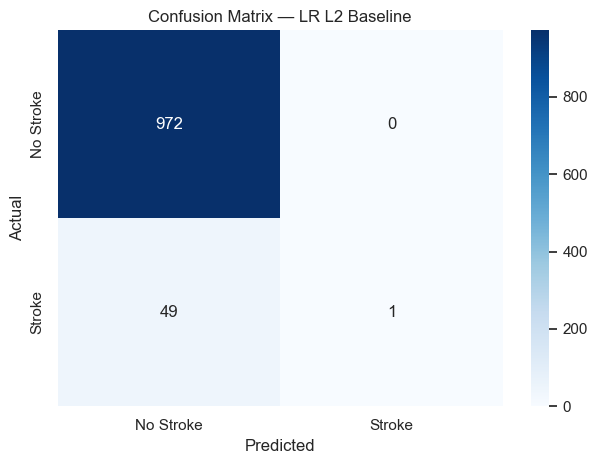

In [16]:
best = lr_l2  # update after reviewing results above
cm = confusion_matrix(y_test, best.predict(X_test_sc))
fig, ax = plt.subplots()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Stroke', 'Stroke'],
            yticklabels=['No Stroke', 'Stroke'])
ax.set_title('Confusion Matrix — LR L2 Baseline')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'p2_confusion_matrix_baseline.png'), dpi=150)
plt.show()

## 7. ROC Curve

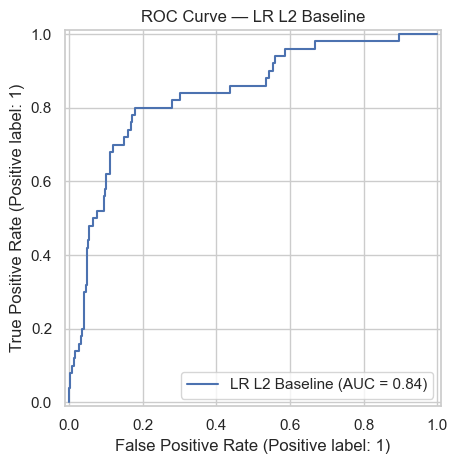

In [17]:
fig, ax = plt.subplots()
RocCurveDisplay.from_estimator(best, X_test_sc, y_test, ax=ax, name='LR L2 Baseline')
ax.set_title('ROC Curve — LR L2 Baseline')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'p2_roc_curve_baseline.png'), dpi=150)
plt.show()

## 8. Save Metrics Table

In [18]:
metrics_df = pd.DataFrame(results)
os.makedirs(os.path.dirname(METRICS_PATH), exist_ok=True)
metrics_df.to_csv(METRICS_PATH, index=False)
display(metrics_df)

,model,precision_stroke,recall_stroke,f1_stroke,roc_auc,accuracy
0,LR Baseline,1.0,0.02,0.039216,0.839424,0.952055
1,LR L1 (C=0.1),0.0,0.00,0.000000,0.839527,0.951076
2,LR L2 (C=0.1),1.0,0.02,0.039216,0.838621,0.952055
